# LangGraph - Parallelization

>Run in Parallel

We can use parallelization to enable LLMs to work on a task simultaneously.

Let’s consider a workflow where a complex task is divided into smaller, independent subtasks. Each subtask is processed simultaneously by the model, with its outputs later combined for a final result.

In [1]:
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from dotenv import load_dotenv
load_dotenv()

True

First, we’ll define the state and initialize an LLM.

In [2]:
# Graph state definition
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

llm = ChatOpenAI(model="gpt-4o-mini")

Next, we will construct a workflow where separate LLM calls generate outputs — a joke, a story, and a poem — all based on a common topic.

In [3]:
def call_llm_1(state: State):
    """First LLM call to generate a joke."""
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def call_llm_2(state: State):
    """Second LLM call to generate a story."""
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}

def call_llm_3(state: State):
    """Third LLM call to generate a poem."""
    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}

def aggregator(state: State):
    """Combine the joke, story, and poem into a single output."""
    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

Now, we need to define a graph with branches.

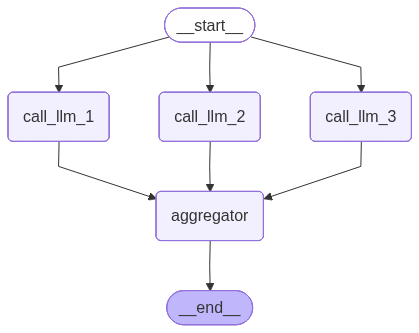

In [4]:
# Build the parallel workflow graph
parallel_builder = StateGraph(State)

# Add each function as a node in the graph
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Define the edges that describe execution order and parallelism
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")

# All branches converge on the aggregator node
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")

# Final edge leads to the end of the workflow
parallel_builder.add_edge("aggregator", END)

# Compile the workflow graph so it’s ready to run
parallel_workflow = parallel_builder.compile()

# Optionally visualize the workflow structure
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [5]:
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Here's a story, joke, and poem about cats!

STORY:
In a quaint little town nestled between rolling hills, there was a unique café called "The Purring Parlor." It was no ordinary café; its charming wooden sign featured a playful painting of a fluffy tabby cat perched atop a steaming cup of coffee. What made this café truly special was its very special staff: a band of feline friends who seemed to be in charge of all things cozy and comfortable.

The owner, a kind-hearted woman named Mabel, had a soft spot for cats. After losing her beloved pet, Whiskers, she decided to adopt a few strays from the local shelter to bring warmth back into her life. Little did she know that these cats would become the heart and soul of The Purring Parlor.

There was Oliver, a majestic Maine Coon with a tufted mane and a dignified demeanor. He held court on the wooden counter, watching over the customers as they sipped their lattes and nibbled on pastries. His favorite pastime was lounging in a sunbeam that 

Each node independently asks the LLM to create a joke, story, or poem about cats.

Once all outputs are ready, the aggregator node collects and formats them into a unified string.

---

To illustrate more advanced parallel workflows, let’s explore a scenario where different branches have varying numbers of steps before converging.

* Both branches begin after node a

* One branch `b` -> `b2` has two steps
* The other branch `c` has only one
* Both parts must finish before node `d` can proceed, ensuring proper synchronization and aggregation of results.

In [6]:
import operator
from typing import Annotated, Any

class State(TypedDict):
    # The reducer makes this append-only for collecting node outputs
    state: Annotated[list, operator.add]

The `state` is defined as a list, and each node appends its unique string to this list as the workflow proceeds.

We can alter the node behavior using a callable class.

In [7]:
class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}

In [8]:
builder = StateGraph(State)

# Each node initialized with its label
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

Here, each node is created with a unique label (*I’m A, I’m B, …*) passed as `node_secret`.

When the node runs (the class instance is called), it prints what it’s adding for visibility and returns a dictionary with its value wrapped in a list: `{"state": [self._value]}`.

This structure works seamlessly with the reducer function `operator.add`, so each node’s output gets appended to the running list in the shared state.

Here, node `"a"` will append `"I'm A"` to the state list, and node `"b"` will append `"I'm B"`, etc.

Essentially, we have created a dynamic node.

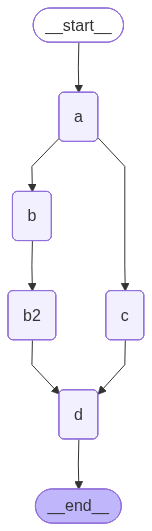

In [9]:
# Edges: Notice the asymmetry in path lengths!
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")  # d waits for both b2 and c
builder.add_edge("d", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

After node `a`, the graph splits: one path (`b` → `b2`) is longer, while the other (`c`) is direct.

Node `d` will only execute after both `b2` and `c` have finished, ensuring all required data is available before proceeding to the end.

In [11]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]}

**Node `“a”` runs first**

* Output: `Adding I'm A to []`

* State becomes: `["I'm A"]`

**Node `“b”`:**

* Output: `Adding I'm B to ["I'm A"]`

* State: `["I'm A", "I'm B"]`

**Node `“c”` (runs in parallel with `“b”`):**

* Output: `Adding I'm C to ["I'm A"]`

* State: `["I'm A", "I'm B", "I'm C"]`  
(Order of `“b”` and `“c”` in the output may vary based on execution, but both follow `“a”`)

**Node `“b2”` waits for `“b”`**

* Output: `Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]`

* State: `["I'm A", "I'm B", "I'm C", "I'm B2"]`

**Node `“d”` waits for both `“b2”` and `“c”`**

* Output: `Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]`

* Final state: `["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]`

---

To demonstrate parallelization in a real-world information retrieval workflow, let’s design a system that answers user questions by searching both the web and Wikipedia in parallel, and then synthesizing the results into a single answer.

In [17]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.tools import TavilySearchResults

class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]

Both `search_web` and `search_wikipedia` are invoked immediately after the workflow starts, working independently to retrieve documents related to the user’s question.

In [18]:
def search_web(state):
    """Retrieve docs from web search."""
    search = TavilySearchResults(max_results=3)
    search_docs = search.invoke(state['question'])
    return {"context": [search_docs]} 

def search_wikipedia(state):
    """Retrieve docs from Wikipedia."""
    search_docs = WikipediaLoader(query=state['question'], load_max_docs=2).load()
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )
    return {"context": [formatted_search_docs]} 

The `generate_answer` node waits for both search nodes to finish, then receives the combined context. It constructs a prompt for the LLM, instructing it to write a comprehensive answer using both sources.

In [19]:
def generate_answer(state):
    """Node to answer a question."""
    context = state["context"]
    question = state["question"]
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question, context=context)
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content="Answer the question.")])
    return {"answer": answer}

Let’s build the workflow.

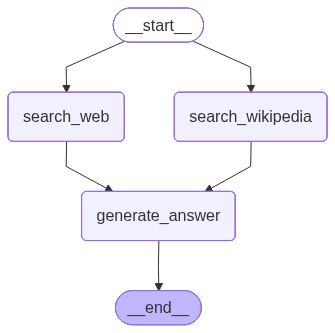

In [20]:
# Add nodes
builder = StateGraph(State)

# Initialize each node with node_secret 
builder.add_node("search_web",search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# Flow
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
result = graph.invoke({"question": "How were Nvidia's Q2 2024 earnings"})
print(result['answer'].content)

Nvidia's Q2 2024 earnings were outstanding, with the company reporting a record revenue of $13.51 billion. This represents an 88% increase sequentially and a 101% increase year-on-year. The growth was primarily driven by the Data Center segment, which saw $10.32 billion in revenue, marking a 171% increase year-over-year. Nvidia's gaming division also performed well, with revenue increasing by 22% from the previous year to $2.49 billion. The earnings per share were $2.70, surpassing analysts' expectations. Additionally, Nvidia announced a $25 billion share buyback, boosting investor confidence. Overall, the strong demand for Nvidia's AI and accelerated computing products contributed significantly to these results.


The parallel structure maximizes both efficiency and completeness, leading to high-quality answers that draw from the broadest possible base of knowledge.